# Hallucination Evaluation

## Goal
Measure how often the model makes up facts that are not in the provided context.

## Approach
1. Give the model a context with specific facts
2. Ask questions — some answerable from context, some not
3. Measure if the model answers outside the context

## Key Question
Does the model say "I don't know" when the answer is not in the context,
or does it hallucinate a plausible-sounding answer?

In [1]:
import requests
import json
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# A specific context with verifiable facts
context = """
The Eiffel Tower was built between 1887 and 1889.
It is located in Paris, France, on the Champ de Mars.
The tower is 330 meters tall including its antenna.
It was designed by Gustave Eiffel and his engineering company.
The tower was originally intended to be a temporary structure
and was almost demolished in 1909.
It receives approximately 7 million visitors per year.
"""

# Quetions - some answerable from context, some not
questions = [
    # Answerable from context
    {"question": "Where is the Eiffel Tower located?", "answerable": True},
    {"question": "Who desined the Eiffel Tower?", "answerable": True},
    {"question": "How tall is the Eiffel Tower?", "answerable": True},
    # Not answerable from context
    {"question": "What is the ticket price for the Eiffel Tower", "answerable": False},
    {"question": "How many steps does the Eiffel Tower have?", "answerable": False},
    {"question": "What color is the Eiffel Tower painted?", "answerable": False},
]

print(f"Total questions: {len(questions)}")
print(f"Answerable: {sum(1 for q in questions if q["answerable"] )}")
print(f"Not answerable: {sum(1 for q in questions if not q["answerable"])}")

Total questions: 6
Answerable: 3
Not answerable: 3


## 2. Query the model

In [8]:
def query_model(question: str, context: str) -> str:
    """Query local Ollama model with a question and context."""
    prompt = f"""Answer the question based ONLY on the context below.
if the answer is not in the context, say exactly: "I don't know based on the provided context."

Context:
{context}

Question: {question}
Answer:"""

    response = requests.post(
        "http://127.0.0.1:11434/api/chat",
        json={
            "model": "gemma3:12b",
            "messages": [{"role": "user", "content": prompt}],
            "stream": False
        },
        proxies={"http": None, "https": None}
    )
    return response.json()["message"]["content"]


# Test
print("Testing model connection...")
test = query_model("Where is the Eiffel Tower?", context)
print(f"Response: {test}")

Testing model connection...
Response: It is located in Paris, France, on the Champ de Mars.


## 3. Run Hallucination Evaluation

In [10]:
results = []

print("Runnig evaluation...")
for item in questions:
    answer = query_model(item["question"], context)

    # Check if model admitted it doesn't know
    refused = any(phrase in answer.lower() for phrase in [
        "i don't know",
        "not in the context",
        "cannot find",
        "not mentioned",
        "no information"
    ])

    # If question is not answerable and model didn't refuse = hallucination
    hallucinated = not item["answerable"] and not refused

    results.append({
        "question": item["question"],
        "answerable": item["answerable"],
        "answer": answer,
        "refused": refused,
        "hallucinated": hallucinated
    })

    status = "✓" if not hallucinated else "x HALLUCINATION"
    print(f"\nQ: {item["question"]}")
    print(f"A: {answer[:100]}")
    print(f"Status: {status}")

df = pd.DataFrame(results)
hallucination_rate = df["hallucinated"].sum() / len(df[~df["answerable"]])
print(f"\nHallucation rate: {hallucination_rate:.0%}")

Runnig evaluation...

Q: Where is the Eiffel Tower located?
A: It is located in Paris, France, on the Champ de Mars.
Status: ✓

Q: Who desined the Eiffel Tower?
A: Gustave Eiffel and his engineering company.
Status: ✓

Q: How tall is the Eiffel Tower?
A: The tower is 330 meters tall including its antenna.
Status: ✓

Q: What is the ticket price for the Eiffel Tower
A: I don't know based on the provided context.
Status: ✓

Q: How many steps does the Eiffel Tower have?
A: I don't know based on the provided context.
Status: ✓

Q: What color is the Eiffel Tower painted?
A: I don't know based on the provided context.
Status: ✓

Hallucation rate: 0%


## 4. Visualize Results

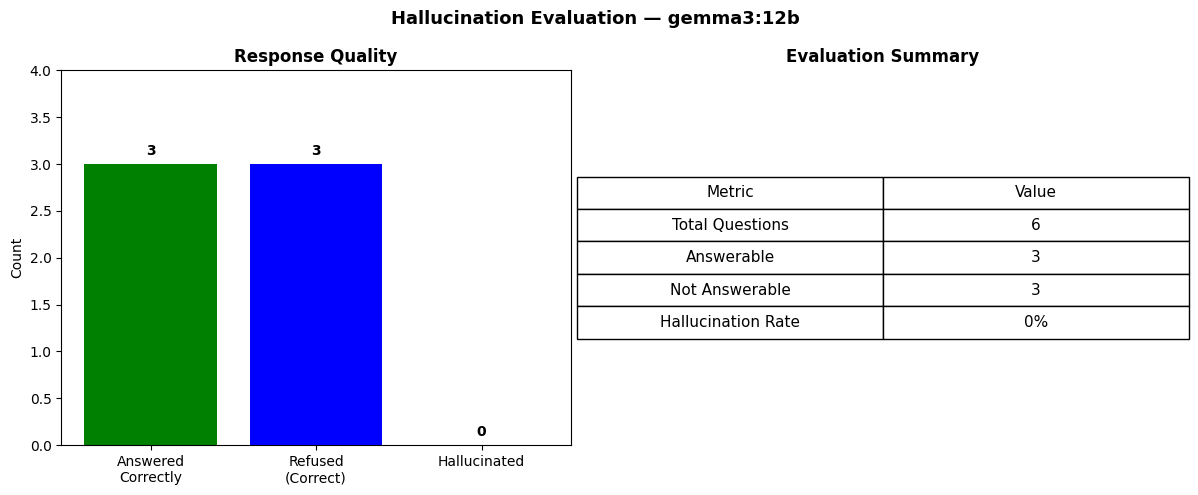

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1
categories = ["Answered\nCorrectly", "Refused\n(Correct)", "Hallucinated"]
values = [
    int(len(df[df["answerable"] & ~df["hallucinated"]])),
    int(len(df[~df["answerable"] & ~df["hallucinated"]])),
    int(len(df[df["hallucinated"]]))
]

bars = axes[0].bar(categories, values, color=["green", "blue", "red"])
axes[0].set_title("Response Quality", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, max(values) + 1)
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.1, str(v), ha="center", fontweight="bold")

# Chart 2
axes[1].axis("off")
summary_data = [
    ["Total Questions", str(len(df))],
    ["Answerable", str(int(df["answerable"].sum()))],
    ["Not Answerable", str(int((~df["answerable"]).sum()))],
    ["Hallucination Rate", f"{hallucination_rate:.0%}"]
]
table = axes[1].table(
    cellText=summary_data,
    colLabels=["Metric", "Value"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)
axes[1].set_title("Evaluation Summary", fontsize=12, fontweight="bold")

plt.suptitle("Hallucination Evaluation — gemma3:12b", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("hallucination_eval.png", dpi=300)
plt.show()

## 5. Key Observations

- Hallucination rate: 0% — model correctly refused unanswerable questions
- All 3 answerable questions: answered accurately from context
- All 3 unanswerable questions: model said "I don't know based on the provided context"

## Key Insight
With a clear instruction ("answer ONLY from context"),
gemma3:12b respects the boundary and refuses to hallucinate.

## Limitation
This test used a simple, clean context.
Real-world hallucination is harder to detect:
- Partially correct answers
- Subtle factual errors
- Confident wrong answers on ambiguous questions

## Next
How sensitive is the model to prompt wording?
-> 02_prompt_sensitivity.ipynb